## Test Transformation


In [1]:
import os
import sys

# Le chemin cible (le dossier "Segmentation")
nouveau_chemin = '/home/tibia/Projet_Hemorragie/Seg_hemorragie/Segmentation/'

# 1. Changer le répertoire de travail (CWD)
os.chdir(nouveau_chemin)

# 2. (Optionnel mais recommandé) Ajouter le nouveau chemin au PYTHONPATH
# Cela permet d'importer des modules Python depuis ce dossier.
sys.path.append(nouveau_chemin) 

# Afficher le nouveau CWD pour vérification
print(f"Le nouveau répertoire de travail est : {os.getcwd()}") 

Le nouveau répertoire de travail est : /store/home/tibia/Projet_Hemorragie/Seg_hemorragie/Segmentation


In [2]:
import config as cfg
import warnings
import pytorch_lightning as pl
import data.dataset as dataset

cfg=cfg.CONFIG


train_files = dataset.get_data_files(
    f"{cfg['dataset']['dataset_dir']}/train/img",
    f"{cfg['dataset']['dataset_dir']}/train/seg"
)

print(f"Nombre de cas d'entraînement : {len(train_files)}")

Nombre de cas d'entraînement : 192


Test de la transformation sur l'image : /home/tibia/Projet_Hemorragie/Split_MBH_V2/train/img/ID_0237f3c9_ID_40015688b9.nii.gz
Avec le label de segmentation : /home/tibia/Projet_Hemorragie/Split_MBH_V2/train/seg/ID_0237f3c9_ID_40015688b9.nii.gz
 Quelles hemorragies sont présentes dans ce cas ?
Labels numériques bruts trouvés : {0.0, 2.0, 3.0}
Hémorragies présentes : intraparenchymal, intraventricular
--------------------------------------------------
Taille du patch image (C x H x L x P) : torch.Size([1, 96, 96, 96])
Taille du patch label (C x H x L x P) : torch.Size([1, 96, 96, 96])
Valeurs min/max de l'image (doivent être entre 0.0 et 1.0 après ScaleIntensityRanged) : 0.00 / 1.00
--------------------------------------------------


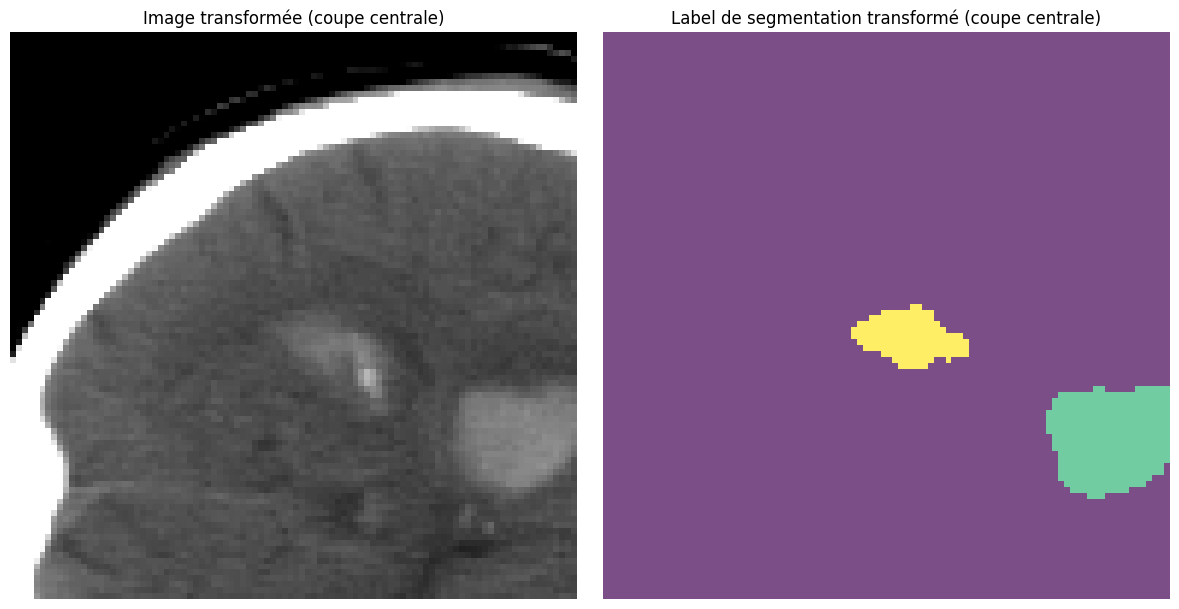

In [6]:
import data.transform as T_seg
from monai.data import Dataset,PersistentDataset,DataLoader
import matplotlib.pyplot as plt
import nibabel as nib
#MAPPAGE DES HEMORRHAGIES
HEMORRHAGE_MAP = {
    1.0: 'epidural',
    2.0: 'intraparenchymal',
    3.0: 'intraventricular',
    4.0: 'subarachnoid',
    5.0: 'subdural'
}

single_case = train_files[0]
print(f"Test de la transformation sur l'image : {single_case['image']}")
print(f"Avec le label de segmentation : {single_case['seg']}")


print(" Quelles hemorragies sont présentes dans ce cas ?")
try:
    label_nib = nib.load(single_case['seg'])
    label_data = label_nib.get_fdata()
    # Récupérer tous les labels uniques (ex: {0.0, 1.0, 4.0})
    unique_labels = set(label_data.flatten())
    
    print(f"Labels numériques bruts trouvés : {unique_labels}")

    # --- 3. Traduire les labels en noms ---
    present_hemorrhages = [
        HEMORRHAGE_MAP[label] 
        for label in unique_labels 
        if label in HEMORRHAGE_MAP  # Cela ignore le 0.0 (fond) et autres labels inconnus
    ]

    # --- 4. Afficher le résultat ---
    if present_hemorrhages:
        # Utilise .join() pour créer une belle chaîne de caractères
        print(f"Hémorragies présentes : {', '.join(present_hemorrhages)}")
    else:
        print("Aucune hémorragie (selon le mappage) n'est présente dans ce fichier.")

except Exception as e:
    print(f"Erreur lors de la lecture du fichier de segmentation : {e}")

train_transforms = T_seg.get_train_transforms(cfg)

test_dataset = PersistentDataset(data=[single_case], transform=train_transforms, cache_dir="./cache_dir")


transformed_data = test_dataset[0][0]
#print(transformed_data)
image_tensor = transformed_data['image']
label_tensor = transformed_data['seg'] 

print("-" * 50)
print(f"Taille du patch image (C x H x L x P) : {image_tensor.shape}")
print(f"Taille du patch label (C x H x L x P) : {label_tensor.shape}")
print(f"Valeurs min/max de l'image (doivent être entre 0.0 et 1.0 après ScaleIntensityRanged) : {image_tensor.min():.2f} / {image_tensor.max():.2f}")
print("-" * 50)

# Affichage visuel (pour vérifier les transformations aléatoires et le croppage)
# On prend la coupe centrale pour une visualisation 2D
slice_idx = image_tensor.shape[-1] // 2 

plt.figure("Vérification des Transformations d'Entraînement", (12, 6))

plt.subplot(1, 2, 1)
plt.title("Image transformée (coupe centrale)")
# On retire le canal (C=1) pour l'affichage 2D
plt.imshow(image_tensor.cpu().numpy()[0, :, :, slice_idx], cmap="gray") 
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Label de segmentation transformé (coupe centrale)")
# On retire le canal (C=1) pour l'affichage 2D
plt.imshow(label_tensor.cpu().numpy()[0, :, :, slice_idx], cmap="viridis", alpha=0.7) # alpha pour voir l'image sous le masque
plt.axis('off')

plt.tight_layout()
plt.show()


Test de la transformation sur l'image : /home/tibia/Projet_Hemorragie/Split_MBH_V2/train/img/ID_0237f3c9_ID_40015688b9.nii.gz
Avec le label de segmentation : /home/tibia/Projet_Hemorragie/Split_MBH_V2/train/seg/ID_0237f3c9_ID_40015688b9.nii.gz
Shape image originale : (512, 512, 27)
Shape label original : (512, 512, 27)
Hémorragies présentes (global) : intraparenchymal, intraventricular
--------------------------------------------------
Sélection d'une coupe originale pour affichage : 11
-> Hémorragies trouvées sur CETTE coupe : intraparenchymal

Application des transformations (création du patch)...
Taille du patch image transformé (C x H x L x P) : torch.Size([1, 96, 96, 96])
Taille du patch label transformé (C x H x L x P) : torch.Size([1, 96, 96, 96])
Valeurs min/max de l'image (doivent être entre 0.0 et 1.0) : 0.00 / 1.00
--------------------------------------------------


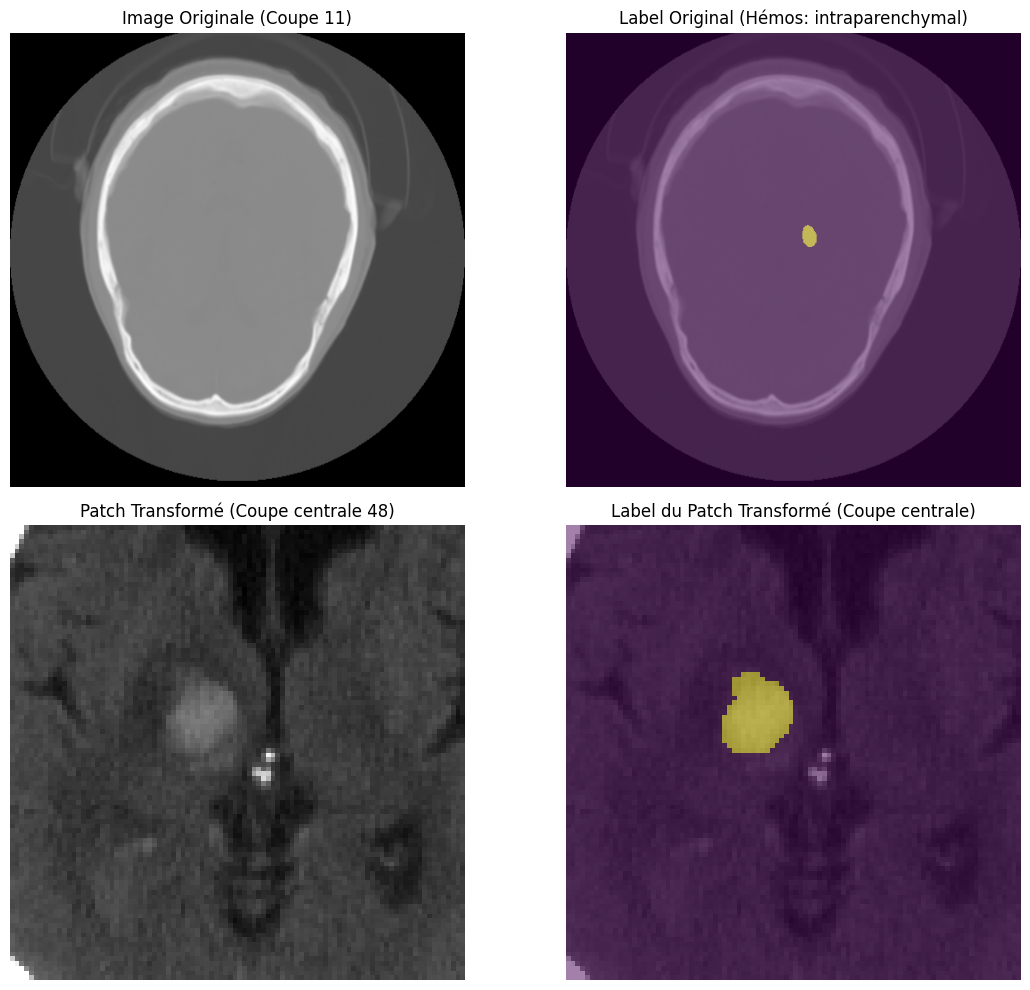

In [7]:
import data.transform as T_seg
from monai.data import Dataset, PersistentDataset, DataLoader
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np  # <-- AJOUT NÉCESSAIRE

# MAPPAGE DES HEMORRHAGIES (inchangé)
HEMORRHAGE_MAP = {
    1.0: 'epidural',
    2.0: 'intraparenchymal',
    3.0: 'intraventricular',
    4.0: 'subarachnoid',
    5.0: 'subdural'
}

# --- 1. OBTENIR LE CAS ET CHARGER LES DONNÉES ORIGINALES ---
single_case = train_files[0]
print(f"Test de la transformation sur l'image : {single_case['image']}")
print(f"Avec le label de segmentation : {single_case['seg']}")

# On charge les données NIfTI originales *avant* les transformations
try:
    image_nib = nib.load(single_case['image'])
    image_data_orig = image_nib.get_fdata()  # (H, W, D)
    
    label_nib = nib.load(single_case['seg'])
    label_data_orig = label_nib.get_fdata()  # (H, W, D)

    print(f"Shape image originale : {image_data_orig.shape}")
    print(f"Shape label original : {label_data_orig.shape}")

    # (Optionnel) Garder votre analyse globale pour info
    unique_labels_global = set(label_data_orig.flatten())
    present_hemorrhages_global = [
        HEMORRHAGE_MAP[label] 
        for label in unique_labels_global 
        if label in HEMORRHAGE_MAP
    ]
    if present_hemorrhages_global:
        print(f"Hémorragies présentes (global) : {', '.join(present_hemorrhages_global)}")
    else:
        print("Aucune hémorragie (global) n'est présente dans ce fichier.")

except Exception as e:
    print(f"Erreur lors de la lecture du fichier NIfTI original : {e}")
    # Gérer l'erreur si nécessaire
    # exit() 

# --- 2. TROUVER UNE COUPE ORIGINALE "INTÉRESSANTE" ---
slice_idx_orig = -1
present_on_slice = ["None"]

# Parcourir les coupes (axe Z, le dernier)
for i in range(label_data_orig.shape[-1]):
    current_slice_data = label_data_orig[:, :, i]
    if np.any(current_slice_data > 0):  # Si un pixel n'est pas 0 (fond)
        slice_idx_orig = i
        slice_labels_raw = set(current_slice_data.flatten())
        present_on_slice = [
            HEMORRHAGE_MAP[label] 
            for label in slice_labels_raw 
            if label in HEMORRHAGE_MAP
        ]
        break  # On a trouvé notre coupe, on arrête la boucle

# Fallback si aucune hémorragie n'est trouvée (image saine)
if slice_idx_orig == -1:
    slice_idx_orig = label_data_orig.shape[-1] // 2
    
print("-" * 50)
print(f"Sélection d'une coupe originale pour affichage : {slice_idx_orig}")
if present_on_slice[0] != "None":
    print(f"-> Hémorragies trouvées sur CETTE coupe : {', '.join(present_on_slice)}")
else:
    print("-> Aucune hémorragie sur cette coupe (ou cas sain).")


# --- 3. APPLIQUER LES TRANSFORMATIONS MONAI ---
train_transforms = T_seg.get_train_transforms(cfg)
test_dataset = PersistentDataset(data=[single_case], transform=train_transforms, cache_dir="./cache_dir")

print("\nApplication des transformations (création du patch)...")
# Le test_dataset[0] applique les transformations
transformed_data = test_dataset[0][0]
image_tensor = transformed_data['image']
label_tensor = transformed_data['seg'] 

print(f"Taille du patch image transformé (C x H x L x P) : {image_tensor.shape}")
print(f"Taille du patch label transformé (C x H x L x P) : {label_tensor.shape}")
print(f"Valeurs min/max de l'image (doivent être entre 0.0 et 1.0) : {image_tensor.min():.2f} / {image_tensor.max():.2f}")
print("-" * 50)


# --- 4. AFFICHAGE COMPARATIF ---

# Pour le patch transformé, on prend la coupe centrale (du patch)
slice_idx_transformed = image_tensor.shape[-1] // 2 

plt.figure("Comparaison Avant/Après Transformation", (12, 10))

# --- Rangée du HAUT : Original ---
plt.subplot(2, 2, 1)
plt.title(f"Image Originale (Coupe {slice_idx_orig})")
# .T et origin="lower" donnent une orientation radiologique plus standard
plt.imshow(image_data_orig[:, :, slice_idx_orig].T, cmap="gray", origin="lower")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title(f"Label Original (Hémos: {', '.join(present_on_slice)})")
# On superpose le label sur l'image
plt.imshow(image_data_orig[:, :, slice_idx_orig].T, cmap="gray", origin="lower")
plt.imshow(label_data_orig[:, :, slice_idx_orig].T, cmap="viridis", alpha=0.5, origin="lower") 
plt.axis('off')

# --- Rangée du BAS : Transformé ---
plt.subplot(2, 2, 3)
plt.title(f"Patch Transformé (Coupe centrale {slice_idx_transformed})")
# On retire le canal (C=1) et on applique .T/origin
plt.imshow(image_tensor.cpu().numpy()[0, :, :, slice_idx_transformed].T, cmap="gray", origin="lower") 
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("Label du Patch Transformé (Coupe centrale)")
# On superpose le label transformé sur l'image transformée
plt.imshow(image_tensor.cpu().numpy()[0, :, :, slice_idx_transformed].T, cmap="gray", origin="lower")
plt.imshow(label_tensor.cpu().numpy()[0, :, :, slice_idx_transformed].T, cmap="viridis", alpha=0.5, origin="lower")
plt.axis('off')

plt.tight_layout()
plt.show()

Chargement du fichier image de base : /home/tibia/Projet_Hemorragie/Split_MBH_V2/train/img/ID_0237f3c9_ID_40015688b9.nii.gz
Chargement du fichier label de base : /home/tibia/Projet_Hemorragie/Split_MBH_V2/train/seg/ID_0237f3c9_ID_40015688b9.nii.gz
--------------------------------------------------
Taille de l'image de base (H x L x P) : (512, 512, 27)
Taille du label de base (H x L x P) : (512, 512, 27)
Valeurs min/max de l'image (unités Hounsfield brutes) : -2048.0 / 3071.0
--------------------------------------------------


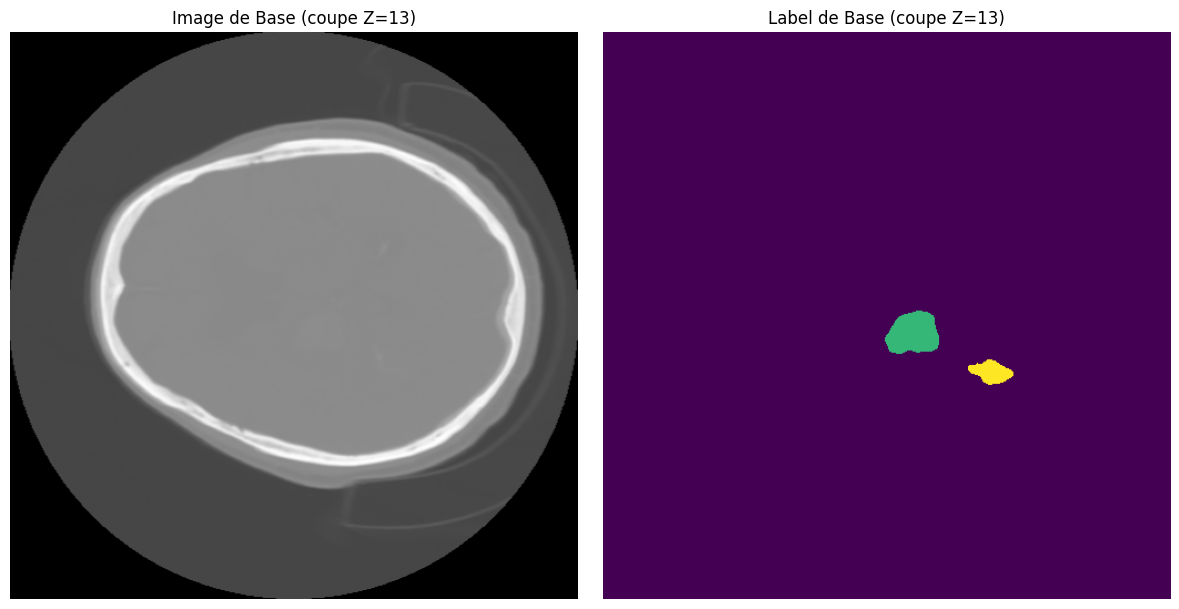


Affichage des données de base terminé. Vérifiez la forme et la présence de l'hémorragie sur le label.


In [24]:
import matplotlib.pyplot as plt
from monai.transforms import LoadImaged, EnsureChannelFirstd
import data.dataset as dataset
import config as cfg
import os
import numpy as np
import monai.transforms as T

# Charger la configuration
cfg = cfg.CONFIG

# --- 1. Obtenir les chemins des fichiers ---
train_files = dataset.get_data_files(
    f"{cfg['dataset']['dataset_dir']}/train/img",
    f"{cfg['dataset']['dataset_dir']}/train/seg"
)

# --- 2. Sélectionner le premier cas ---
# Nous prenons le premier cas de la liste
single_case = train_files[0]

print(f"Chargement du fichier image de base : {single_case['image']}")
print(f"Chargement du fichier label de base : {single_case['seg']}")

# --- 3. Définir le pipeline de chargement de base ---
# Nous utilisons LoadImaged et EnsureChannelFirstd, qui sont les premières étapes
# de tout pipeline de prétraitement, pour obtenir les données brutes.
basic_load_transforms = T.Compose([
    LoadImaged(keys=["image", "seg"]),
    EnsureChannelFirstd(keys=["image", "seg"]),
])

# Appliquer la transformation
# Nous appliquons directement la transformation au dictionnaire de chemins.
data_base = basic_load_transforms(single_case)

# Extraire les tenseurs (ils ne sont pas encore normalisés ni coupés)
image_base = data_base['image'].cpu().numpy().squeeze()
label_base = data_base['seg'].cpu().numpy().squeeze()

# --- 4. Afficher et vérifier les données de base ---
print("-" * 50)
print(f"Taille de l'image de base (H x L x P) : {image_base.shape}")
print(f"Taille du label de base (H x L x P) : {label_base.shape}")
print(f"Valeurs min/max de l'image (unités Hounsfield brutes) : {image_base.min():.1f} / {image_base.max():.1f}")
print("-" * 50)

# Affichage visuel (coupe centrale)
slice_idx = image_base.shape[-1] // 2 

plt.figure("Vérification des Données de Base", (12, 6))

plt.subplot(1, 2, 1)
plt.title(f"Image de Base (coupe Z={slice_idx})")
# On utilise la plage de couleurs par défaut car les valeurs sont brutes (Unités Hounsfield)
plt.imshow(image_base[:, :, slice_idx], cmap="gray") 
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Label de Base (coupe Z={slice_idx})")
# Le masque est binaire (0 ou 1) ou multi-label
plt.imshow(label_base[:, :, slice_idx], cmap="viridis") 
plt.axis('off')

plt.tight_layout()
plt.show()

print("\nAffichage des données de base terminé. Vérifiez la forme et la présence de l'hémorragie sur le label.")

## Test config Sweep

In [5]:
import config
import sweep_config

cfg= config.CONFIG
print (cfg)


sweep_conf=sweep_config.sweep_config
print (sweep_conf)


def update_config_with_wandb(cfg, wb_cfg):
    # Training params
    if "training_batch_size" in wb_cfg:
        cfg["training"]["batch_size"] = wb_cfg.training_batch_size
    if "training_learning_rate" in wb_cfg:
        cfg["training"]["learning_rate"] = wb_cfg.training_learning_rate

    # Augmentation
    if "augmentation_spatial_size" in wb_cfg:
        cfg["augmentation"]["spatial_size"] = eval(wb_cfg.augmentation_spatial_size)

    return cfg

new_conf= update_config_with_wandb(cfg,sweep_conf)
print (new_conf)

{'dataset': {'dataset_dir': '/home/tibia/Projet_Hemorragie/Split_MBH_V2', 'save_dir': '/home/tibia/Projet_Hemorragie/MBH_seg_v2_test_1'}, 'training': {'batch_size': 2, 'num_epochs': 1000, 'optimizer': 'sgd', 'learning_rate': 0.001, 'weight_decay': 3e-05, 'momentum': 0.99}, 'scheduler': {'type': 'linear_warmup', 'num_warmup_steps': 0}, 'model': {'spatial_dims': 3, 'in_channels': 1, 'out_channels': 6, 'channels': (32, 64, 128, 256, 320, 320), 'strides': (2, 2, 2, 2, 2), 'num_res_units': 2}, 'augmentation': {'spatial_size': (96, 96, 64), 'pos_ratio': 5.0, 'neg_ratio': 1.0, 'prob': 0.5}, 'callbacks': {'monitor': 'val_loss', 'mode': 'min', 'save_top_k': 1, 'patience': 50}, 'CHECKPOINT_PATH': '/home/tibia/Projet_Hemorragie/MBH_seg_v2_test_1/checkpoints/best_model.ckpt'}
{'method': 'bayes', 'metric': {'name': 'val_loss', 'goal': 'minimize'}, 'parameters': {'training.batch_size': {'values': [2, 4, 8]}, 'training.optimizer': {'values': ['SGD', 'Adam']}, 'learning_rate': {'min': 0.0001, 'max': 0

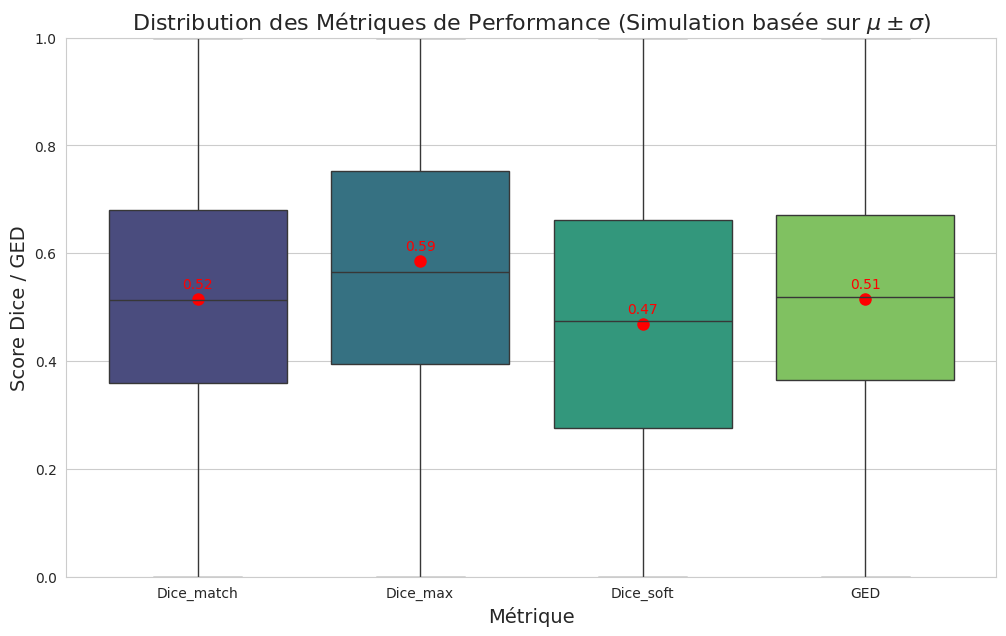

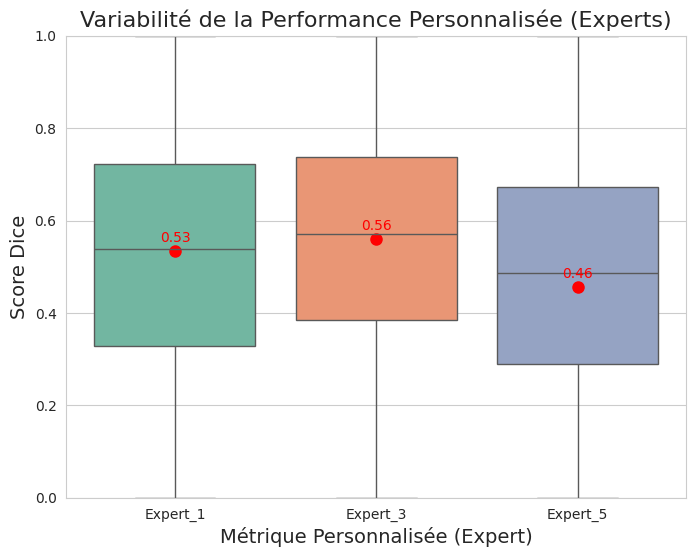

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# 1. Vos données réelles (Moyennes et Écarts Types)
# ==========================================================

metrics_data = {
    'Dice_match': {'mean': 0.5158, 'std': 0.2503},
    'Dice_max': {'mean': 0.5853, 'std': 0.2548},
    'Dice_soft': {'mean': 0.4686, 'std': 0.2874},
    'GED': {'mean': 0.5149, 'std': 0.2359},
    'Expert_1': {'mean': 0.5330, 'std': 0.2743},
    'Expert_3': {'mean': 0.5595, 'std': 0.2663},
    'Expert_5': {'mean': 0.4551, 'std': 0.2777}
}

# ==========================================================
# 2. SIMULATION des Scores pour la Visualisation
# ==========================================================

# Nous allons simuler une distribution (par exemple, 1000 scores)
# en utilisant la moyenne et l'écart type pour chaque métrique.
# Ceci permet de visualiser la dispersion comme si vous aviez tous les scores
# de chaque cas (le "vrai" Box Plot).

N_SAMPLES = 1000
simulated_scores = {}

for name, stats in metrics_data.items():
    # Génère des scores aléatoires avec une distribution normale
    scores = np.random.normal(loc=stats['mean'], scale=stats['std'], size=N_SAMPLES)
    
    # S'assurer que les scores restent dans la plage [0, 1]
    scores = np.clip(scores, 0.0, 1.0)
    
    simulated_scores[name] = scores

df = pd.DataFrame(simulated_scores)


# ==========================================================
# 3. CRÉATION DU GRAPHIQUE (Box Plot)
# ==========================================================

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Crée le Box Plot
# Box Plot est le meilleur choix pour visualiser la moyenne, la médiane, et la dispersion (IQR)
sns.boxplot(data=df[['Dice_match', 'Dice_max', 'Dice_soft', 'GED']], palette="viridis")

# Ajoute les moyennes (en rouge)
for i, metric in enumerate(['Dice_match', 'Dice_max', 'Dice_soft', 'GED']):
    mean_val = metrics_data[metric]['mean']
    plt.plot(i, mean_val, marker='o', color='red', markersize=8, label='Moyenne' if i == 0 else "")
    plt.text(i, mean_val + 0.02, f'{mean_val:.2f}', ha='center', color='red', fontsize=10)

plt.title("Distribution des Métriques de Performance (Simulation basée sur $\\mu \\pm \\sigma$)", fontsize=16)
plt.ylabel("Score Dice / GED", fontsize=14)
plt.xlabel("Métrique", fontsize=14)
plt.ylim(0, 1)

plt.show()

# ==========================================================
# 4. CRÉATION DU GRAPHIQUE (Box Plot) pour la Performance Personnalisée
# ==========================================================

plt.figure(figsize=(8, 6))

# Crée le Box Plot pour les experts (si vous les comparez)
sns.boxplot(data=df[['Expert_1', 'Expert_3', 'Expert_5']], palette="Set2")

# Ajoute les moyennes (en rouge)
for i, metric in enumerate(['Expert_1', 'Expert_3', 'Expert_5']):
    mean_val = metrics_data[metric]['mean']
    plt.plot(i, mean_val, marker='o', color='red', markersize=8, label='Moyenne' if i == 0 else "")
    plt.text(i, mean_val + 0.02, f'{mean_val:.2f}', ha='center', color='red', fontsize=10)

plt.title("Variabilité de la Performance Personnalisée (Experts)", fontsize=16)
plt.ylabel("Score Dice", fontsize=14)
plt.xlabel("Métrique Personnalisée (Expert)", fontsize=14)
plt.ylim(0, 1)

plt.show()